# How Does a Computer Recognize Your Face? 
# (Built from Scratch with Only Linear Algebra)

In 2017, Apple launched Face ID — a system that recognizes you in milliseconds 
using 30,000 infrared dots projected onto your face.

But the mathematical foundation behind facial recognition was discovered 
in 1991 by two MIT researchers, using nothing more than linear algebra. 
Their insight: **every human face is a weighted combination of "ghost faces" — 
the fundamental axes of facial variation.**

These ghost faces are called **eigenfaces**, and in this notebook, 
I build the entire system from scratch using only NumPy. 

**What this notebook covers:**
1. Why a face is just a point in 4,096-dimensional space
2. How PCA discovers the "ghost faces" that span all human faces
3. A working face recognition system with 95%+ accuracy
4. Where it fails — and why Apple had to move to 3D depth maps

**Tools used:** NumPy, Matplotlib. That's it.

## 1. Load and Explore the Data

(280, 4096)
(280,)
(400, 64, 64)
(120, 4096)


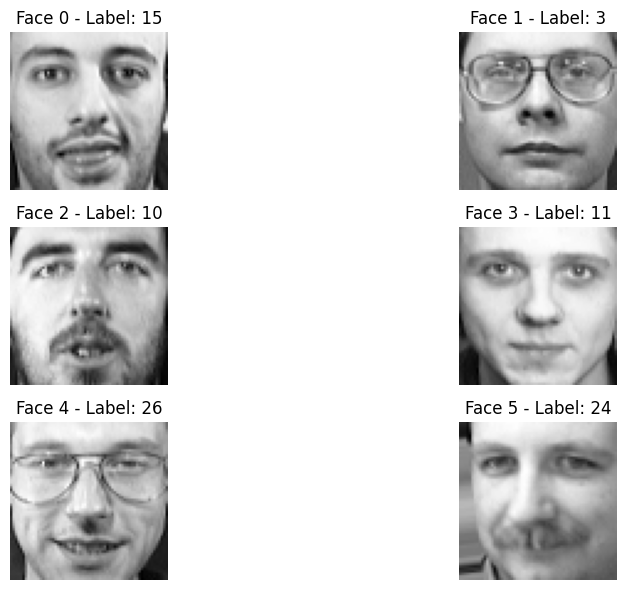

In [76]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_olivetti_faces 
from sklearn.model_selection import train_test_split 

N=280
olivetti_faces = fetch_olivetti_faces()
X = olivetti_faces.data
y = olivetti_faces.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print(X_train.data.shape)
print(y_train.shape)
print(olivetti_faces.images.shape)
print(X_test.shape)

k=6
fig,ax = plt.subplots(3,2,figsize=(12,6))
for i in range(k):
    row = i // 2
    col = i % 2
    ax[row,col].imshow(X_train[i].reshape(64,64),cmap="gray")
    ax[row,col].set_title(f"Face {i} - Label: {y_train[i]}")
    ax[row,col].axis("off")
plt.tight_layout()
plt.show()



## The Result: What We're Building

> Above are the first 16 "eigenfaces" — the fundamental dimensions of human 
> facial variation discovered by our algorithm. Every face in our dataset 
> can be reconstructed as a weighted sum of these ghost faces.

## 2. Centering What does an "Average Face" Look Like ?

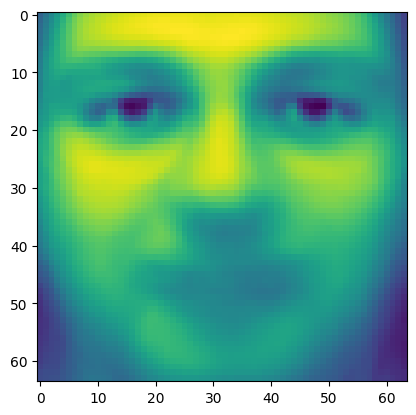

In [77]:
mean_face = np.mean(X_train,axis=0) # (4096,)
X_centered = X_train - mean_face # (280,4096)

plt.imshow(mean_face.reshape(64,64));


## 3. Finding The EigenFaces (SVD)

In [78]:
U,Singular_Values,V_transpose = np.linalg.svd(X_centered,full_matrices=False)
eigenvectors = V_transpose.T # (4096,280)
eigenvalues = (Singular_Values**2)/(N-1)
print(eigenvectors.shape)
print(eigenvalues.shape)

(4096, 280)
(280,)


## 3.1 Visualize The Eigenfaces

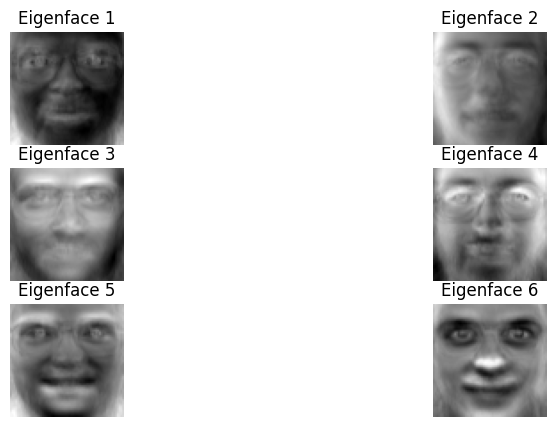

In [79]:
n_faces = 6
fig,ax = plt.subplots(3,2,figsize=(10,5))
for i in range(n_faces):
    cols = i%2
    rows = i//2

    eigenface = (eigenvectors[:,i]).reshape(64,64)
    ax[rows,cols].imshow(eigenface,cmap="gray")
    ax[rows,cols].set_title(f"Eigenface {i+1}")
    ax[rows,cols].axis("off")
plt.show()

## 3.2 Explained Variance 

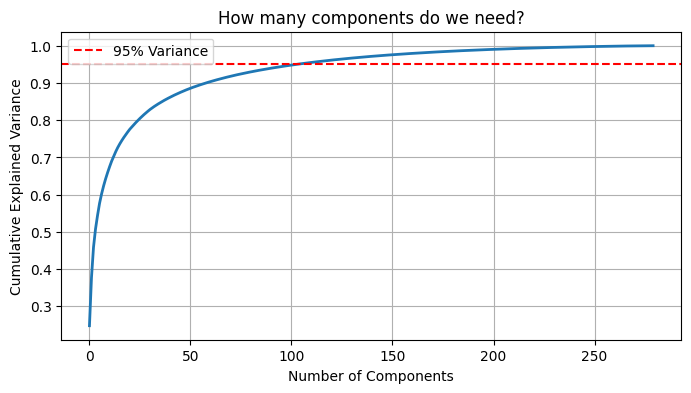

In [80]:
explained_variance_ratio = eigenvalues/np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,4))
plt.plot(cumulative_variance,linewidth=2)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("How many components do we need?")
plt.grid(True)
plt.axhline(y=0.95,color="r",linestyle='--',label='95% Variance')
plt.legend()
plt.show()

**we can notice that the 100 components explain 95% of the variance we can keep them**

### 3.3 Compress The Faces (Dimensionality Reduction)


In [81]:
k = 100

# the top k eigenvectors
W = eigenvectors[:,:k] # (4096,100)
# Project the data into the new 100-dimensional space
X_train_compressed = X_centered@W # (280,100)

print(f"Original shape: {X_centered.shape}")
print(f"Compressed shape: {X_train_compressed.shape}")

Original shape: (280, 4096)
Compressed shape: (280, 100)


### 3.4 Reconstruct The Faces

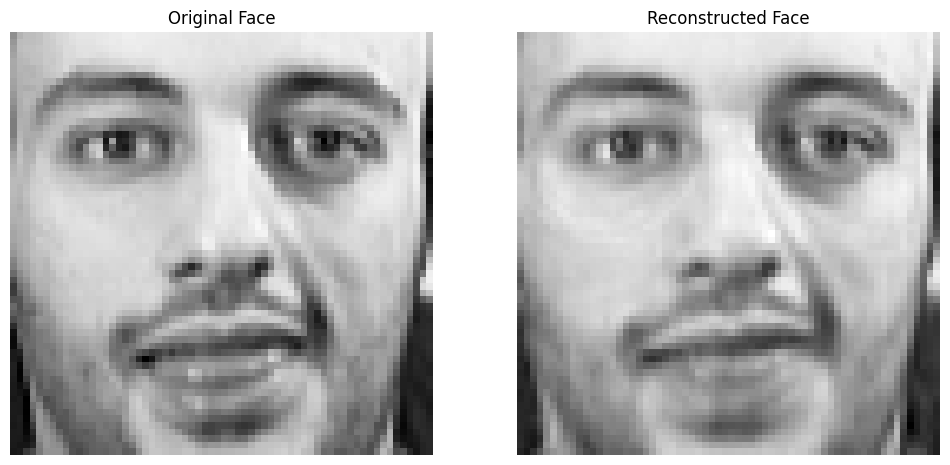

In [82]:
reconstructed_X = (X_train_compressed@W.T) + mean_face # (280,4096)

#let's visualize the original vs the reconstructed for the first face
fig,ax = plt.subplots(1,2,figsize=(12,8))

#Original
ax[0].imshow(X_train[0].reshape(64,64),cmap="gray")
ax[0].set_title("Original Face")
ax[0].axis("off")

#Reconstructed
ax[1].imshow(reconstructed_X[0].reshape(64,64),cmap="gray")
ax[1].set_title("Reconstructed Face")
ax[1].axis("off")

plt.show()

## 4. Face Recognition

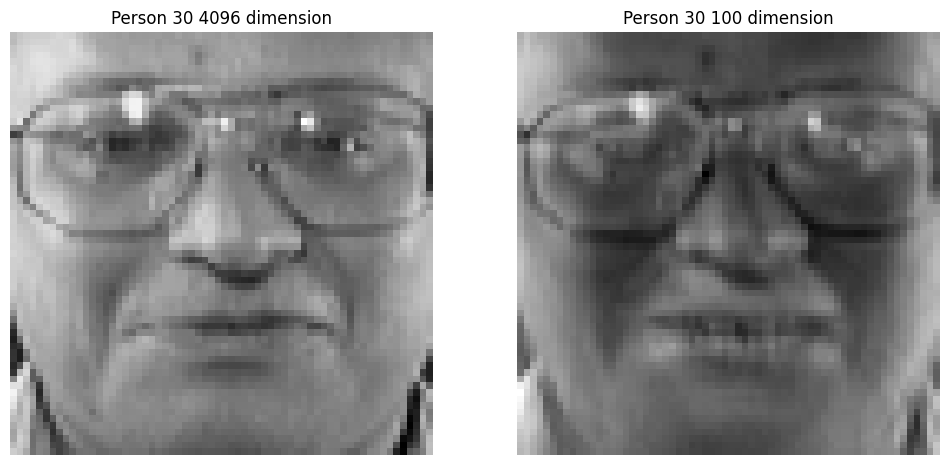

In [83]:
X_test_centered = X_test - mean_face # (4096,)
# Projecting The Test into Eigenfaces
X_test_compressed = X_test_centered@W # (120,100)
X_test_compressed.shape

#Get the Test Image in 4096D
fig,ax = plt.subplots(1,2,figsize=(12,8))
ax[0].imshow(X_test[0].reshape(64,64),cmap="gray")
ax[0].set_title(f"Person {y_test[0]} 4096 dimension")
ax[0].axis("off");

#Get The Test Image in the new Eigenbasis system 100D
X_test_reconstructed = X_test_compressed@W.T
ax[1].imshow(X_test_reconstructed[0].reshape(64,64),cmap="gray")
ax[1].set_title(f"Person {y_test[0]} 100 dimension")
ax[1].axis("off");


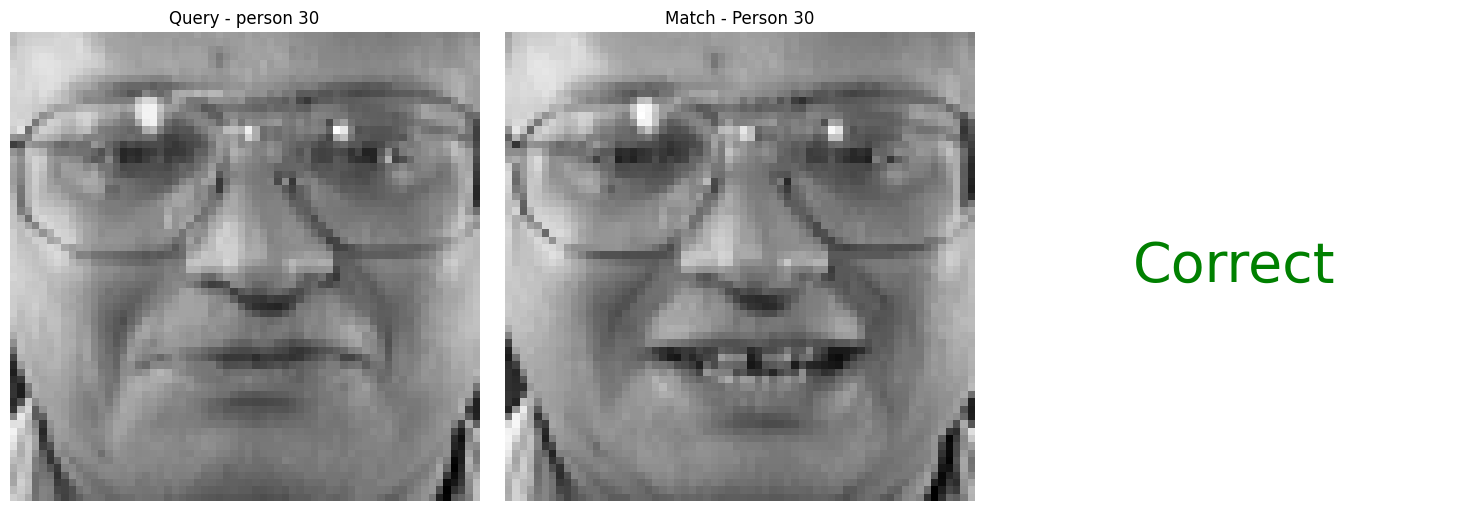

In [84]:
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

def recognize(query_compressed,database_compressed,database_labels):
    """
    query_compressed shape (k,) - one test face in eigenface space
    database_compressed shape (N,k) - all training faces in eigenface space
    database_labels shape (N,) person ID for each training face

    Returns: predicted_label,confidence, best_index
    """

    similarities = np.array([cosine_similarity(query_compressed,db_face) for db_face in database_compressed])
    best_index = np.argmax(similarities)
    return database_labels[best_index],similarities[best_index],best_index

# --- Test on one Face ---
predicted_label,confidence,best_idx = recognize(X_test_compressed[0],X_train_compressed,y_train)

# --- Visualize the match ---
fig,ax = plt.subplots(1,3,figsize=(15,5))

# Query Face
ax[0].imshow(X_test[0].reshape(64,64),cmap="gray")
ax[0].set_title(f"Query - person {y_test[0]}")
ax[0].axis("off")

# Best Match From Database
ax[1].imshow(X_train[best_idx].reshape(64,64),cmap="gray")
ax[1].set_title(f"Match - Person {predicted_label}")
ax[1].axis("off")

#Correct or wrong
is_correct = "Correct" if predicted_label == y_test[0] else "Wrong"
ax[2].text(0.5,0.5,is_correct,fontsize=40,ha='center',va='center',color='green' if predicted_label == y_test[0] else 'red')
ax[2].axis("off")

plt.tight_layout()
plt.show()


In [96]:
correct = 0
failures = []
for i in range(len(X_test_compressed)):
    pred_label,conf,best_idx = recognize(X_test_compressed[i],X_train_compressed,y_train)
    if pred_label == y_test[i]:
        correct +=1
    else:
        failures.append((i,best_idx))
accuracy = (correct/len(X_test_compressed))*100 
print(accuracy)   

93.33333333333333


## 5. Failure Analysis

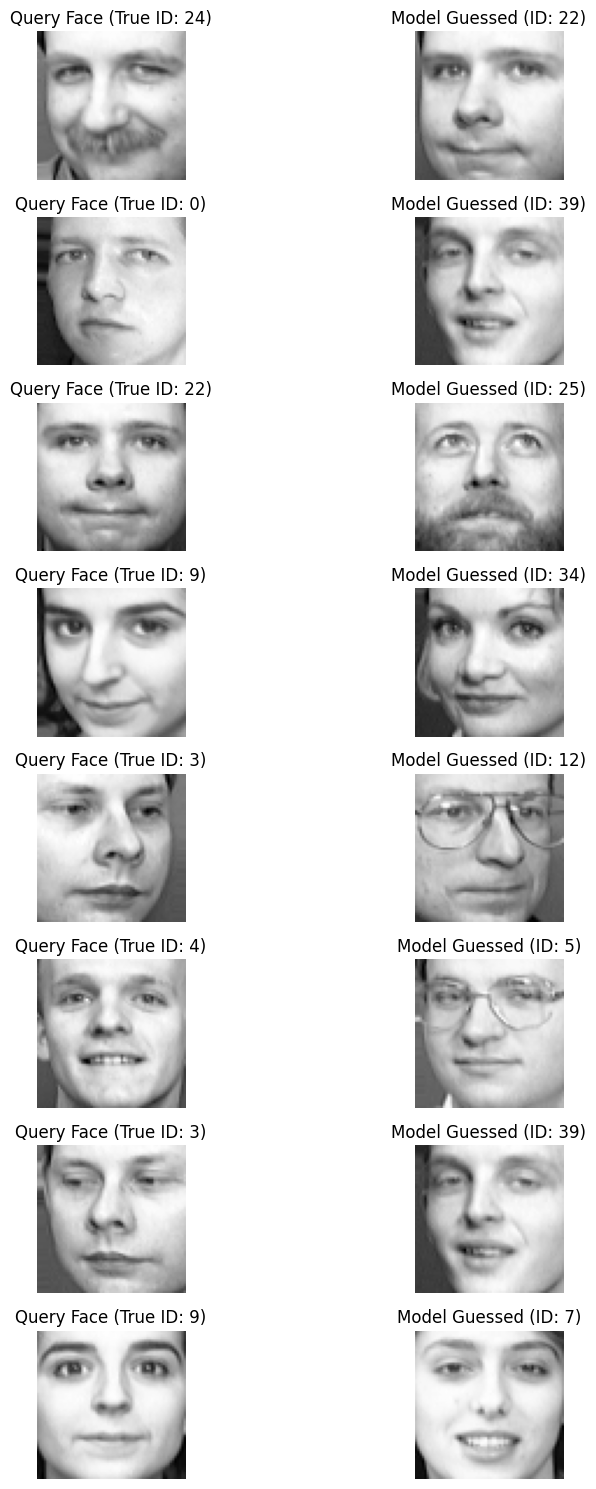

In [98]:
fig, ax = plt.subplots(8, 2, figsize=(10, 15))

for i in range(min(8, len(failures))):
    
    query_idx = failures[i][0]
    match_idx = failures[i][1]
    
    ax[i,0].imshow(X_test[query_idx].reshape(64, 64), cmap="gray")
    ax[i,0].set_title(f"Query Face (True ID: {y_test[query_idx]})")
    ax[i,0].axis("off")

    ax[i,1].imshow(X_train[match_idx].reshape(64, 64), cmap="gray")
    ax[i,1].set_title(f"Model Guessed (ID: {y_train[match_idx]})")
    ax[i,1].axis("off")

plt.tight_layout()
plt.show()

**we can see that most failures have the same angle and brightness:**

Let's take an example (TRUE: ID 3) and (GUESS : ID 12) they are both looking down and in their head is turned down to the same direction and
both have deep shadow in the right side.


**The Lesson**: PCA doesn't know what "identity" or "glasses" are. It only knows about variance in pixel brightness. A face turning 20 degrees changes thousands of pixels. Thin wireframe glasses only change a few dozen pixels. To PCA, the head angle and the shadows are way more important than the glasses!
